In [2]:
# 한국어 출력 위함
%%capture
!pip install koreanize-matplotlib
import koreanize_matplotlib

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('/content/drive/MyDrive/mid/WHR_2018_2022.csv')
df.head()

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,year
0,Finland,Western Europe,7.632,1.305,1.592,0.874,0.681,0.202,0.393,2018
1,Norway,Western Europe,7.594,1.456,1.582,0.861,0.686,0.286,0.340,2018
2,Denmark,Western Europe,7.555,1.351,1.590,0.868,0.683,0.284,0.408,2018
3,Iceland,Western Europe,7.495,1.343,1.644,0.914,0.677,0.353,0.138,2018
4,Switzerland,Western Europe,7.487,1.420,1.549,0.927,0.660,0.256,0.357,2018


In [ ]:
check = df[['country','happiness_score','gdp_per_capita','social_support','healthy_life_expectancy']]
check = check.sort_values(by='happiness_score',ascending=True)

,country,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy
755,Afghanistan,2.4040,0.758000,0.000000,0.289000
610,Afghanistan,2.5230,0.370000,0.000000,0.126000
461,Afghanistan,2.5669,0.300706,0.356434,0.266052
460,South Sudan,2.8166,0.289083,0.553279,0.208809
308,South Sudan,2.8530,0.306000,0.575000,0.295000
152,Burundi,2.9050,0.091000,0.627000,0.145000
754,Lebanon,2.9550,1.392000,0.498000,0.631000
753,Zimbabwe,2.9950,0.947000,0.690000,0.270000
307,Central African Republic,3.0830,0.026000,0.000000,0.105000
151,Central African Republic,3.0830,0.024000,0.000000,0.010000


In [5]:
# 각 나라별로 평균값 계산
df_avg = df.groupby('country').agg({
    'region' : lambda x: x.mode()[0],
    'happiness_score': 'mean',
    'social_support': 'mean',
    'gdp_per_capita' : 'mean',
    'healthy_life_expectancy' : 'mean'
}).reset_index()

df_avg.sort_values(by='happiness_score', ascending=True).head(20).reset_index(drop=True)

,country,region,happiness_score,social_support,gdp_per_capita,healthy_life_expectancy
0,Afghanistan,South Asia,2.865780,0.282087,0.422141,0.259410
1,South Sudan,Sub-Saharan Africa,2.974533,0.578760,0.310694,0.226936
2,Central African Republic,Sub-Saharan Africa,3.213967,0.000000,0.030357,0.038333
3,Rwanda,Sub-Saharan Africa,3.347460,0.492975,0.436649,0.491077
4,Zimbabwe,Sub-Saharan Africa,3.358840,0.918967,0.510513,0.313808
5,Syria,Middle East and North Africa,3.462000,0.380000,0.654000,0.489500
6,Tanzania,Sub-Saharan Africa,3.467040,0.777135,0.533833,0.409536
7,Botswana,Sub-Saharan Africa,3.498980,0.988739,1.131510,0.413820
8,Burundi,Sub-Saharan Africa,3.557575,0.384894,0.034250,0.243803
9,Malawi,Sub-Saharan Africa,3.577000,0.415674,0.262907,0.386633


### **상관관계**

social_support	        0.784235<br>
gdp_per_capita	        0.802863<br>
healthy_life_expectancy	0.787096<br>

높은 상관관계를 보인다.

In [14]:
# 수치형 컬럼만 선택
num = df_avg.select_dtypes(include='number')
# 변수간 상관관계 파악
corr = num.corr()
corr

,happiness_score,social_support,gdp_per_capita,healthy_life_expectancy
happiness_score,1.000000,0.784235,0.802863,0.787096
social_support,0.784235,1.000000,0.758639,0.723118
gdp_per_capita,0.802863,0.758639,1.000000,0.859819
healthy_life_expectancy,0.787096,0.723118,0.859819,1.000000


In [6]:
# 컬럼명 한글 변환 딕셔너리 (출력)
column_mapping = {
    'happiness_score': '행복 점수',
    'social_support': '사회적 지원',
    'gdp_per_capita': '1인당 GDP',
    'healthy_life_expectancy': '건강 기대수명',
    'freedom_to_make_life_choices': '삶의 선택 자유',
    'generosity': '관대함',
    'perceptions_of_corruption': '부패 인식'
}

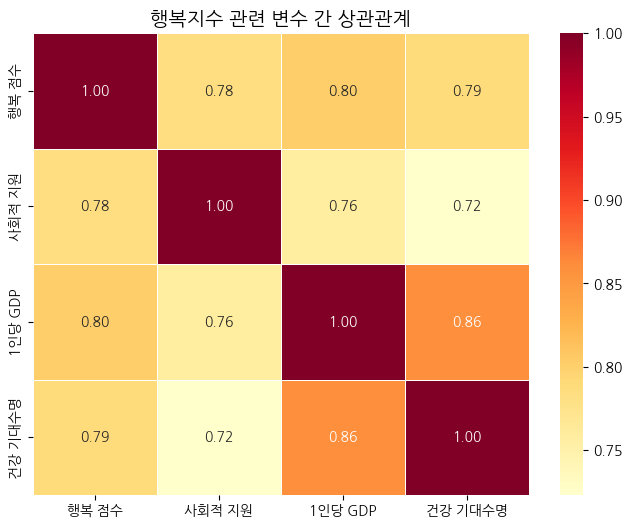

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
# 히트맵 (한글 변수명 적용)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5,
            xticklabels=[column_mapping[col] for col in corr.columns],
            yticklabels=[column_mapping[col] for col in corr.index])

# 제목
plt.title('행복지수 관련 변수 간 상관관계', fontsize=14)

# 그래프 출력
plt.show()

### HEATMAP

In [11]:
df_avg_all = df.groupby('country').mean(numeric_only=True).reset_index()


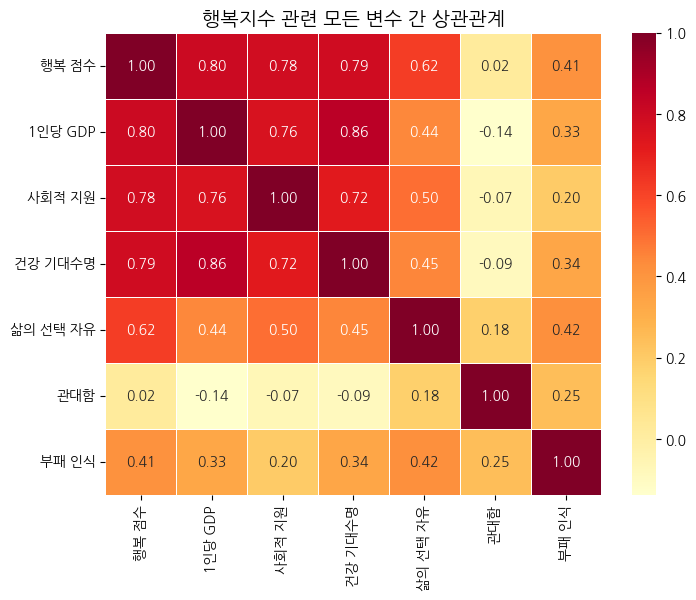

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt


# 2. 수치형 컬럼 선택 (모든 변수 포함)
num = df_avg_all[['happiness_score', 'gdp_per_capita', 'social_support',
              'healthy_life_expectancy', 'freedom_to_make_life_choices',
              'generosity', 'perceptions_of_corruption']]

# 3. 변수 간 상관관계 계산
corr = num.corr()

# 4. 히트맵 그리기 (한글 변수명 적용 & 0.9부터 강조)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap="YlOrRd", linewidths=0.5,
            xticklabels=[column_mapping[col] for col in corr.columns],
            yticklabels=[column_mapping[col] for col in corr.index])

# 5. 히트맵 제목 추가
plt.title('행복지수 관련 모든 변수 간 상관관계', fontsize=14)

# 6. 그래프 출력
plt.show()


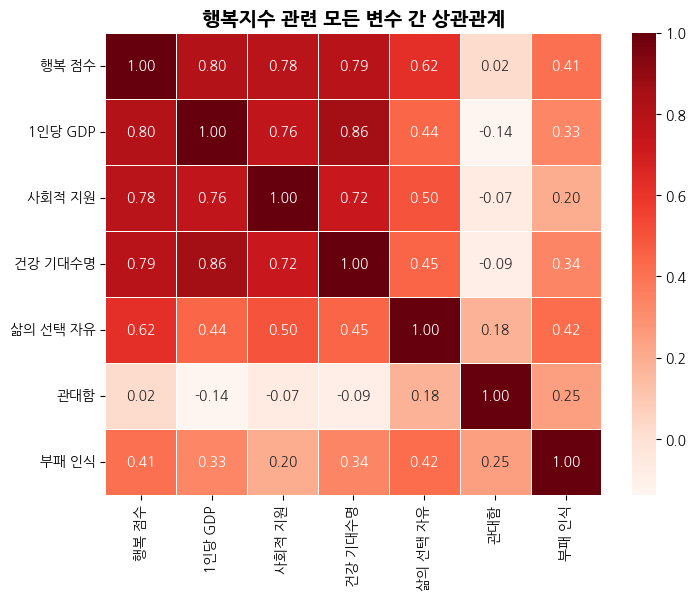

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. 수치형 컬럼 선택 (모든 변수 포함)
num = df_avg_all[['happiness_score', 'gdp_per_capita', 'social_support',
              'healthy_life_expectancy', 'freedom_to_make_life_choices',
              'generosity', 'perceptions_of_corruption']]

# 3. 변수 간 상관관계 계산
corr = num.corr()

# 4. 히트맵 그리기 (한글 변수명 적용 & 0.9부터 강조)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap="Reds", linewidths=0.5,
            xticklabels=[column_mapping[col] for col in corr.columns],
            yticklabels=[column_mapping[col] for col in corr.index])

# 5. 히트맵 제목 추가
plt.title('행복지수 관련 모든 변수 간 상관관계', fontsize=14, fontweight='bold')

# 6. 그래프 출력
plt.show()


In [27]:
corr['happiness_score']

,happiness_score
happiness_score,1.000000
gdp_per_capita,0.802863
social_support,0.784235
healthy_life_expectancy,0.787096
freedom_to_make_life_choices,0.620745
generosity,0.022007
perceptions_of_corruption,0.409696


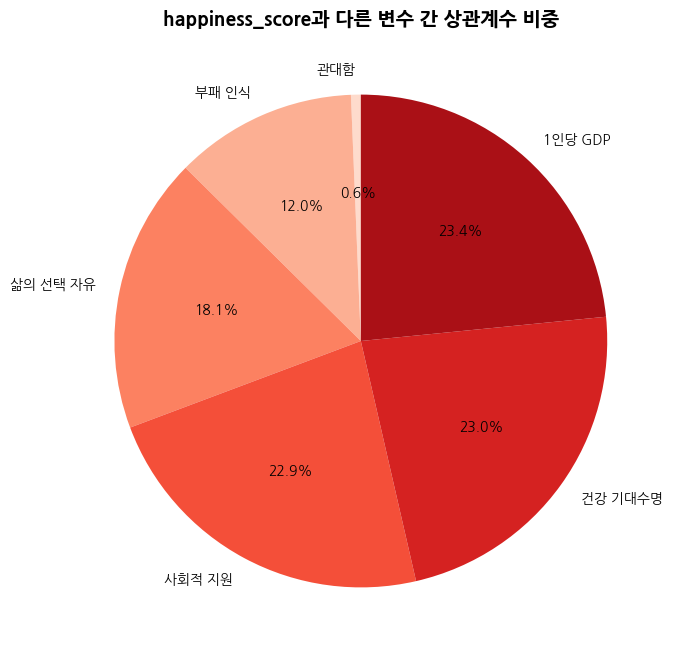

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# happiness_score에 대한 상관계수 값
corr_values = {
    'gdp_per_capita': 0.802863,
    'social_support': 0.784235,
    'healthy_life_expectancy': 0.787096,
    'freedom_to_make_life_choices': 0.620745,
    'generosity': 0.022007,
    'perceptions_of_corruption': 0.409696
}

# 상관계수 값 내림차순으로 정렬
sorted_corr_values = dict(sorted(corr_values.items(), key=lambda item: item[1], reverse=False))

# 색상
colors = sns.color_palette("Reds", len(sorted_corr_values))

# 한글 변수명을 사용한 파이차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(sorted_corr_values.values(),
        labels=[column_mapping[col] for col in sorted_corr_values.keys()],
        autopct='%1.1f%%', startangle=90,
        colors=colors)

# 제목 추가
plt.title('happiness_score과 다른 변수 간 상관계수 비중', fontsize=14, fontweight='bold')

# 그래프 출력
plt.show()


In [ ]:
# bottom 20 저장
bottom20 = df_avg.head(20)

bottom20.to_csv('bottom20.csv', index=False)

In [ ]:
b = pd.read_csv('/content/bottom20.csv')
b.head()

,country,region,happiness_score,social_support,gdp_per_capita,healthy_life_expectancy
0,Afghanistan,South Asia,2.86578,0.282087,0.422141,0.259410
1,Albania,Central and Eastern Europe,4.90074,0.734097,1.043331,0.775066
2,Algeria,Middle East and North Africa,5.10402,1.038401,1.046771,0.682484
3,Argentina,Latin America and Caribbean,6.06894,1.270909,1.189493,0.756555
4,Armenia,Central and Eastern Europe,4.84776,0.931515,0.980852,0.701971


In [ ]:
# 전체 통합 데이터 가져오기
all = pd.read_csv('/content/WHR_2018_2022.csv')

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# country 컬럼 목록
bottom20['country'].tolist()

['Afghanistan',
 'Albania',
 'Algeria',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahrain',
 'Bangladesh',
 'Belarus',
 'Belgium',
 'Benin',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Bulgaria',
 'Burkina Faso']

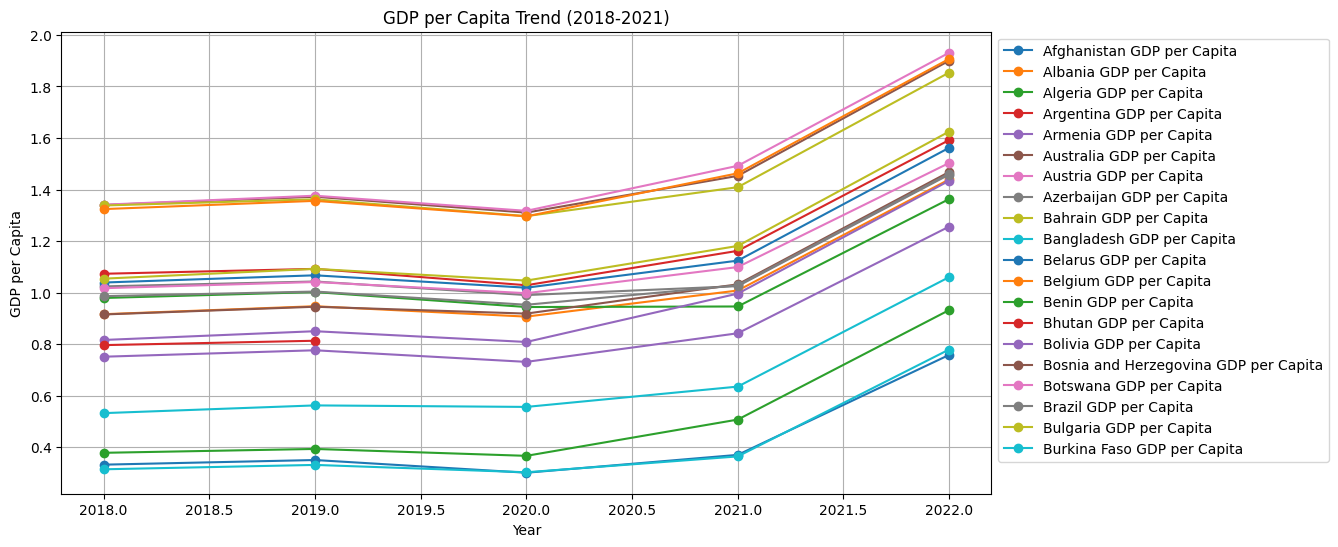

In [ ]:
# 시계열분석 gdp_per_capita
countries = ['Afghanistan', 'Albania', 'Algeria', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan',
             'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
             'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso']

plt.figure(figsize=(12, 6))
for country in countries:
    country_data = df[df['country'] == country]
    plt.plot(country_data['year'], country_data['gdp_per_capita'], marker='o', label=f'{country} GDP per Capita')

plt.xlabel('Year')
plt.ylabel('GDP per Capita')
plt.title('GDP per Capita Trend (2018-2021)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 레이블을 그래프 오른쪽에 배치
plt.grid(True)
plt.show()


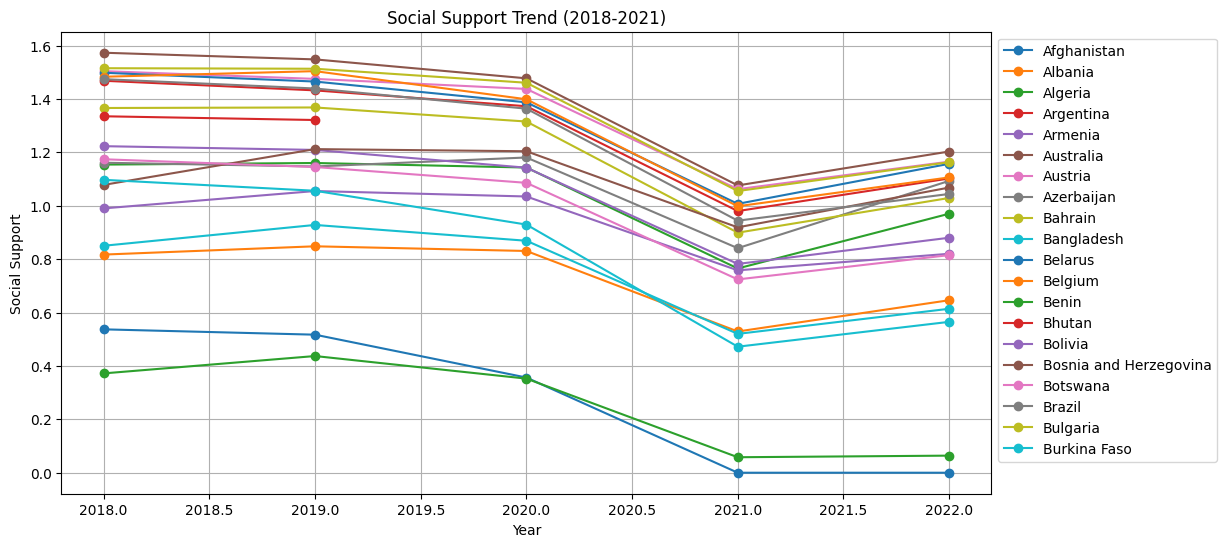

In [ ]:
# 시계열분석 social_support
plt.figure(figsize=(12, 6))
for country in countries:
    country_data = df[df['country'] == country]
    plt.plot(country_data['year'], country_data['social_support'], marker='o', label=f'{country}')

plt.xlabel('Year')
plt.ylabel('Social Support')
plt.title('Social Support Trend (2018-2021)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 레이블을 그래프 오른쪽에 배치
plt.grid(True)
plt.show()

**Social Support** <br>
"2020-2021년" 급격히 감소<br>
-> tableau 에서 분석 시 **모든 나라가 감소**한 것을 볼 수 있었다.

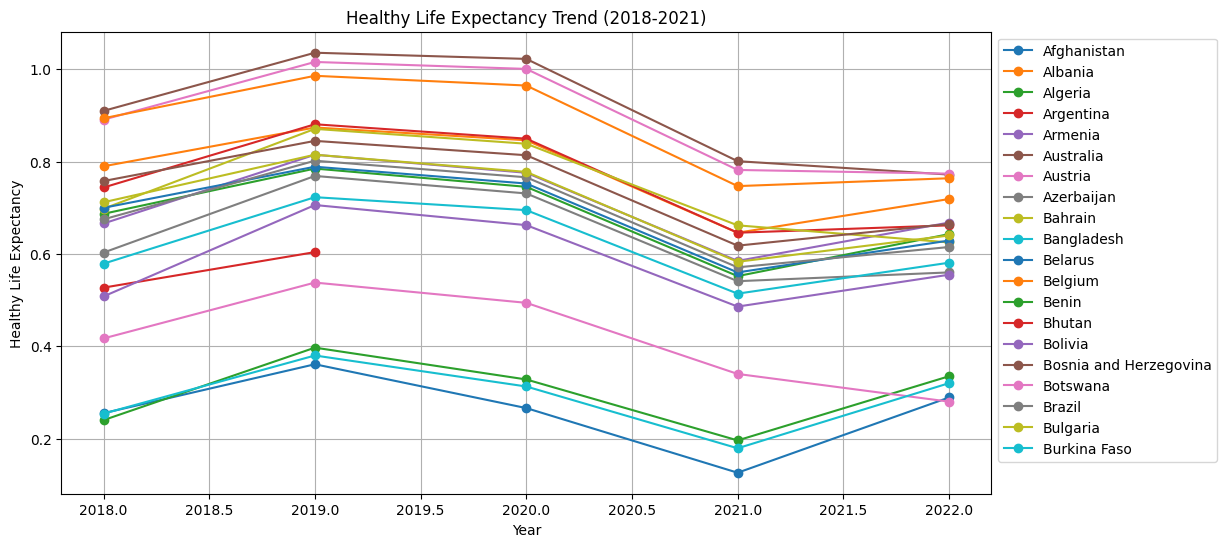

In [ ]:
# 시계열분석 healthy_life_expectancy
plt.figure(figsize=(12, 6))
for country in countries:
    country_data = df[df['country'] == country]
    plt.plot(country_data['year'], country_data['healthy_life_expectancy'], marker='o', label=f'{country}')

plt.xlabel('Year')
plt.ylabel('Healthy Life Expectancy')
plt.title('Healthy Life Expectancy Trend (2018-2021)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 레이블을 그래프 오른쪽에 배치
plt.grid(True)
plt.show()

<ipython-input-42-bebfaf5f9b08>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bottom_20['Group'] = 'Bottom 20'
<ipython-input-42-bebfaf5f9b08>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20['Group'] = 'Top 20'
<ipython-input-42-bebfaf5f9b08>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=col, data=df_boxplot, palette=['red', 'blu

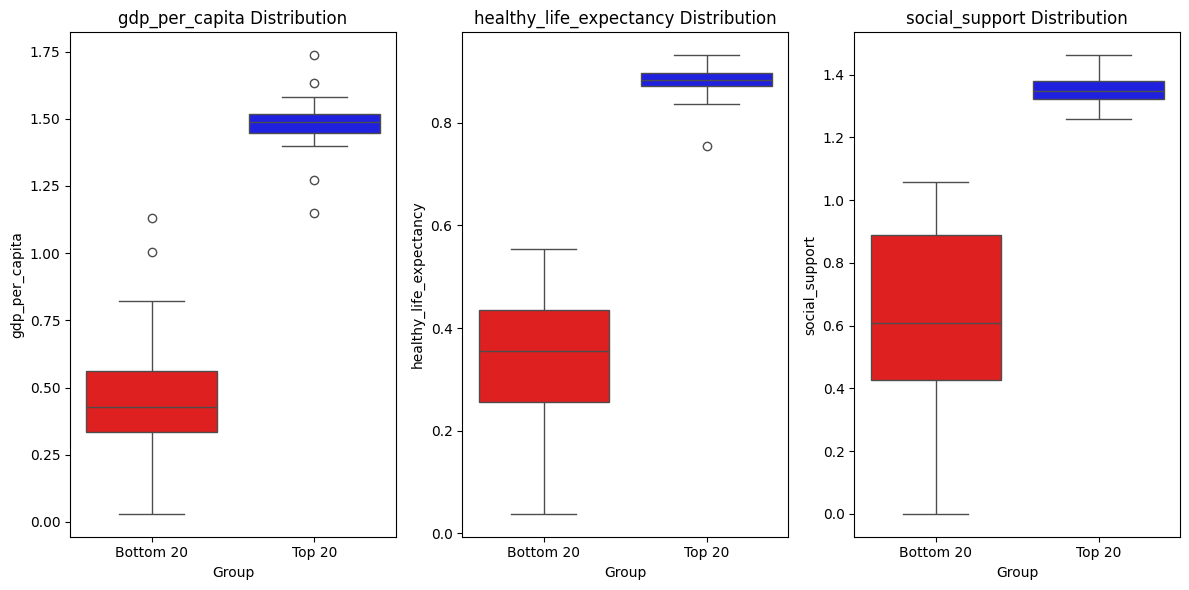

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터프레임 df 가정 (나라별 평균값이 계산된 상태)
# 행복 점수를 기준으로 정렬
df_sorted = df_avg.sort_values(by='happiness_score', ascending=True)

# 하위 20개국 (Bottom 20)
bottom_20 = df_sorted.head(20)

# 상위 20개국 (Top 20)
top_20 = df_sorted.tail(20)

# 데이터에 그룹 정보 추가
bottom_20['Group'] = 'Bottom 20'
top_20['Group'] = 'Top 20'

# 두 데이터를 합치기
df_boxplot = pd.concat([bottom_20, top_20])

# 박스플롯 그리기
plt.figure(figsize=(12, 6))

# 변수별 박스플롯
for i, col in enumerate(['gdp_per_capita', 'healthy_life_expectancy', 'social_support']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x='Group', y=col, data=df_boxplot, palette=['red', 'blue'])
    plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()

In [ ]:
bottom20

모든 변수에서 bottom20이 더 낮은 값을 보임.<br>
하지만 gdp에 이상치 보임<br>
→ **gdp가 높지만 행복지수는 낮은 국가**는?

      country  gdp_per_capita  happiness_score
118    Rwanda        0.436649          3.34746
156  Zimbabwe        0.510513          3.35884
135     Syria        0.654000          3.46200
138  Tanzania        0.533833          3.46704
16   Botswana        1.131510          3.49898
154     Yemen        0.428340          3.62348
77    Lesotho        0.541188          3.65736
58      India        0.822915          3.87486
155    Zambia        0.626967          4.01528
39      Egypt        1.003046          4.26148


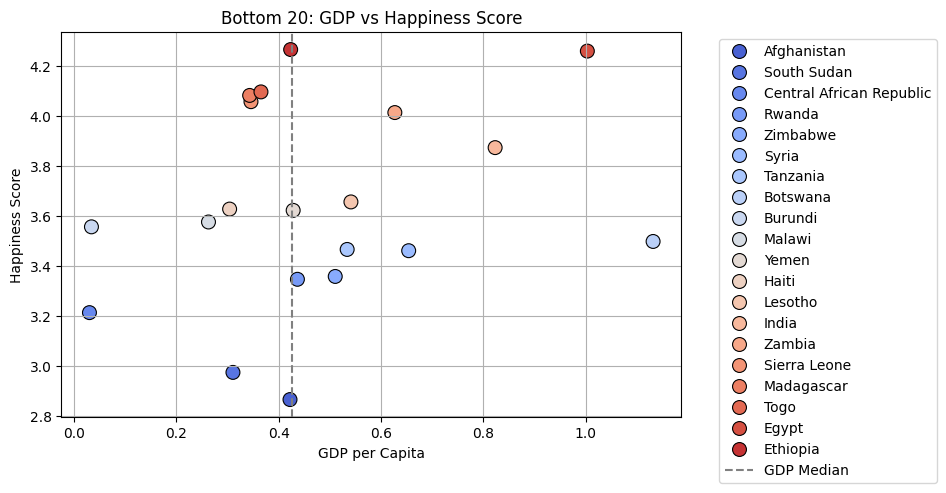

In [ ]:
# GDP 높은데 행복지수 낮은 국가
# Bottom 20 데이터
bottom_20 = df_sorted.head(20).copy()

# Bottom 20 중 GDP가 높은 국가 찾기 (GDP 상위 50% 이상인 국가)
gdp_median = bottom_20['gdp_per_capita'].median()  # 중위값 계산
high_gdp_low_happiness = bottom_20[bottom_20['gdp_per_capita'] > gdp_median]

# 결과 출력
print(high_gdp_low_happiness[['country', 'gdp_per_capita', 'happiness_score']])

# GDP 대비 happiness score 산점도
plt.figure(figsize=(8, 5))
sns.scatterplot(data=bottom_20, x='gdp_per_capita', y='happiness_score', hue='country', palette='coolwarm', s=100, edgecolor='black')

plt.axvline(gdp_median, color='gray', linestyle='dashed', label='GDP Median')  # GDP 중위값 표시
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.title('Bottom 20: GDP vs Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

중동 및 북아프리카 국가들 : <br>
경제적으로 부유하지만 정치적 자유와 사회적 자유가 제한적인 경우가 많고, 부유한 계층과 빈곤한 계층 간의 불평등이 심각할 수 있습니다. 이로 인해 행복 점수가 상대적으로 낮을 수 있습니다.

### clustering

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

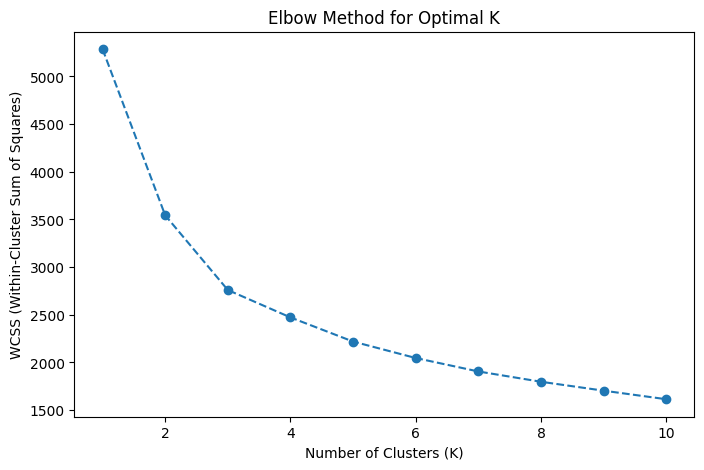

In [ ]:
# 사용할 주요 변수 선택
features = ['country', 'gdp_per_capita', 'happiness_score', 'healthy_life_expectancy', 'social_support',
            'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption']

# 결측치를 제거한 df_cluster
df_cluster = df[features].dropna()  # 결측치 제거

# 'country' 컬럼을 따로 저장
country_column = df_cluster['country']

# 데이터 정규화 (StandardScaler 사용)
scaler = StandardScaler()

# 'country' 컬럼을 제외한 나머지 컬럼만 표준화
df_scaled = df_cluster.drop(columns=['country'])
df_scaled = pd.DataFrame(scaler.fit_transform(df_scaled), columns=df_scaled.columns)

# 다시 country 컬럼을 결합
df_scaled['country'] = country_column

# 적절한 K값 찾기
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled.drop(columns=['country']))  # country 컬럼은 제외하고 클러스터링
    wcss.append(kmeans.inertia_)

# 엘보우 그래프 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.show()


In [ ]:
#k=3
# 클러스터링 작업
kmeans = KMeans(n_clusters=5, random_state=42)
df_scaled['Cluster'] = kmeans.fit_predict(df_scaled.drop(columns=['country']))

# 이후 클러스터링을 진행하고 'country'를 다시 사용할 수 있도록
df_cluster = df_scaled.copy()

# 클러스터별 평균 값 확인 (country 컬럼 제외)
cluster_summary = df_cluster.drop(columns=['country']).groupby('Cluster').mean()
cluster_summary

,gdp_per_capita,happiness_score,healthy_life_expectancy,social_support,freedom_to_make_life_choices,generosity,perceptions_of_corruption
Cluster,,,,,,,
0,-0.583389,-0.447264,-0.494283,-0.311920,0.425490,2.005992,-0.109411
1,0.644121,0.183266,0.020310,-0.275388,0.401895,-0.675207,-0.195161
2,0.047991,0.217181,0.644878,0.775073,-0.274146,-0.313708,-0.515658
3,1.162562,1.435860,1.067786,0.827192,1.002720,0.764372,1.778354
4,-1.119957,-1.097605,-1.234393,-1.036958,-0.676836,0.078151,-0.195757


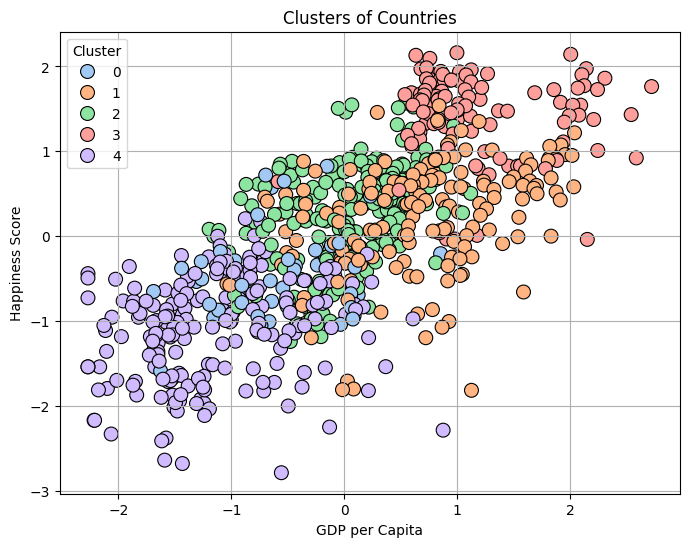

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cluster, x='gdp_per_capita', y='happiness_score', hue=df_cluster['Cluster'], palette='pastel', s=100, edgecolor='black')

plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.title('Clusters of Countries')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
# GDP 높은데 행복 점수 낮은 국가(차이큰순서)

# GDP 중앙값과 Happiness 중앙값 계산
gdp_median = df_avg['gdp_per_capita'].median()
happiness_median = df_avg['happiness_score'].median()

# GDP와 행복 점수 차이 계산
df_avg['gdp_happiness_diff'] = df_avg['gdp_per_capita'] - df_avg['happiness_score']

# 차이가 큰 순서대로 정렬 (내림차순)
df_avg_sorted = df_avg.sort_values(by='gdp_happiness_diff', ascending=False)

# GDP 높은데 행복 점수 낮은 국가들 확인
low_happiness_high_gdp_avg = df_avg_sorted[df_avg_sorted['gdp_per_capita'] > gdp_median]

low_happiness_high_gdp_avg

,country,region,happiness_score,social_support,gdp_per_capita,healthy_life_expectancy,gdp_happiness_diff
16,Botswana,Sub-Saharan Africa,3.49898,0.988739,1.131510,0.413820,-2.367470
76,Lebanon,Middle East and North Africa,4.57310,0.992299,1.055647,0.722934,-3.517454
60,Iran,Middle East and North Africa,4.70728,0.759454,1.125665,0.685611,-3.581615
61,Iraq,Middle East and North Africa,4.69456,0.856493,1.046804,0.514870,-3.647756
45,Gabon,Sub-Saharan Africa,4.83926,0.979680,1.115409,0.451115,-3.723851
...,...,...,...,...,...,...,...
99,Netherlands,Western Europe,7.45138,1.351729,1.508389,0.878535,-5.942991
134,Switzerland,Western Europe,7.52198,1.370481,1.570955,0.931507,-5.951025
57,Iceland,Western Europe,7.52090,1.461513,1.493500,0.903169,-6.027400
36,Denmark,Western Europe,7.61132,1.403490,1.503190,0.876667,-6.108130


In [ ]:
df_avg[df_avg['country'] == 'Zimbabwe']

,country,region,happiness_score,social_support,gdp_per_capita,healthy_life_expectancy
156,Zimbabwe,Sub-Saharan Africa,3.35884,0.918967,0.510513,0.313808


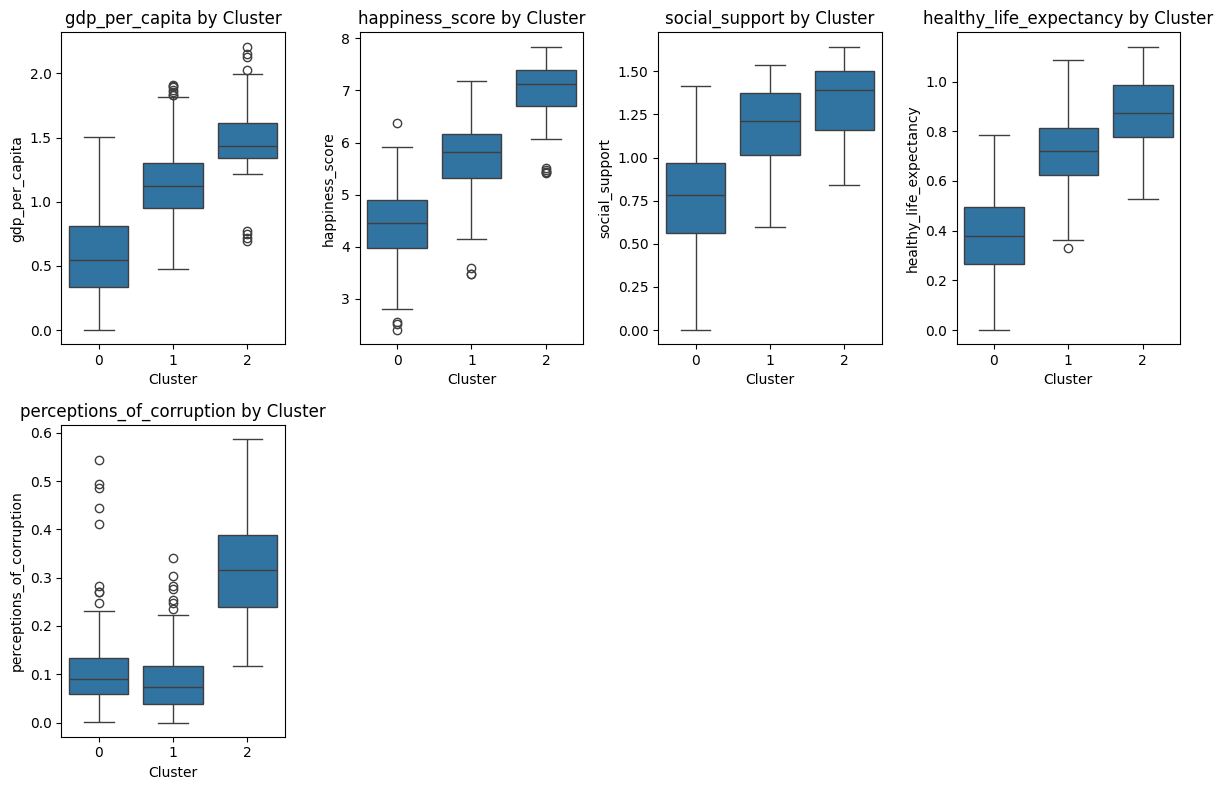

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['gdp_per_capita', 'happiness_score', 'social_support', 'healthy_life_expectancy', 'perceptions_of_corruption']

# 한 줄에 4개씩 표시하기 위해 행 개수 계산
num_features = len(features)
rows = (num_features // 4) + (num_features % 4 > 0)  # 4개씩 나누고 나머지가 있으면 한 줄 추가

plt.figure(figsize=(12, rows * 4))
for i, col in enumerate(features):
    plt.subplot(rows, 4, i + 1)  # 올바른 subplot 개수 적용
    sns.boxplot(x='Cluster', y=col, data=df_cluster)
    plt.title(f'{col} by Cluster')

plt.tight_layout()
plt.show()


In [ ]:
print(df_cluster.columns)


Index(['gdp_per_capita', 'happiness_score', 'healthy_life_expectancy',
       'social_support', 'freedom_to_make_life_choices', 'generosity',
       'perceptions_of_corruption', 'Cluster'],
      dtype='object')


In [ ]:
#